# Auerbach-Kotlikoff Overlapping-Generations Model

## Model Overview

A deterministic OLG model with $T=40$ working periods and $T_R=20$ retirement periods.

**Household preferences** over consumption $c$ and labour $n$:
$$u(c,n) = \frac{\left[(c+\psi_0)(1-n)^\gamma\right]^{1-\sigma}-1}{1-\sigma}$$

**Budget constraints:**
- Worker:  $c^s + a^{s+1} = (1+r)a^s + (1-\tau)w n^s$
- Retiree: $c^s + a^{s+1} = (1+r)a^s + p$

**Optimality conditions — workers:**
$$\frac{u_c(c^s,n^s)}{\beta} = (1+r)\,u_c(c^{s+1},n^{s+1}) \quad \text{(Euler)} \qquad (1-\tau)w\,u_c = u_n \quad \text{(intratemporal)}$$

**Optimality condition — retirees:**
$$\frac{u_c(c^s,0)}{\beta} = (1+r)\,u_c(c^{s+1},0)$$

**Firm (Cobb-Douglas):** $Y = K^\alpha L^{1-\alpha}$
$$r = \alpha K^{\alpha-1}L^{1-\alpha} - \delta \qquad w = (1-\alpha)K^\alpha L^{-\alpha}$$

**Pension (PAYG, budget-balanced):**
$$p = \mathrm{rep}\cdot(1-\tau)\,w\,L\cdot\tfrac{3}{2} \qquad \tau = \frac{\mathrm{rep}}{2+\mathrm{rep}}$$

**Algorithm:** shooting/secant on terminal wealth $a^{T+T_R}$, nested inside a fixed-point iteration on $(K,L)$.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import os

%matplotlib inline
output_dir = "."   # folder for saved plots

In [2]:
import os

# define your output folder
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
os.makedirs(output_dir, exist_ok=True)

## 2. Calibration

All parameters live in a single dict `par` — change one number here and the entire model updates.

In [6]:
# ---------- Preferences ----------
beta0 = 0.96     # subjective discount factor
sigma = 2.0      # CRRA coefficient
gam   = 2.0      # leisure weight in utility
psi0  = 0.001    # utility shifter (avoids corner solutions)

# ---------- Technology ----------
alpha = 0.36     # capital share (Cobb-Douglas)
delta = 0.10     # depreciation rate

# ---------- Demographics & pension ----------
t   = 40
tr  = 20
rep = 0.30                  # replacement ratio
tau = rep / (2.0 + rep)     # tax rate implied by pension budget balance

# ---------- Solver settings ----------
phi  = 0.80    # dampening weight for aggregate updating
tol  = 0.001   # outer-loop convergence tolerance
tolk = 0.001   # inner-loop convergence tolerance on a^1
nq1  = 30      # max inner iterations (shooting)
nq   = 30      # max outer iterations (K, L)

par = dict(
    psi0=psi0, gam=gam, sigma=sigma,
    alpha=alpha, beta0=beta0, delta=delta,
    tr=tr, t=t, tau=tau, rep=rep
)

print(f'Tax rate tau = {tau:.4f}  (rep = {rep})')
print(f'Total cohorts: {t+tr}  ({t} working + {tr} retired)')

Tax rate tau = 0.1304  (rep = 0.3)
Total cohorts: 60  (40 working + 20 retired)


## 3. Utility and Firm Functions

### 3a. Preferences
$$u_c = (c+\psi_0)^{-\sigma}(1-n)^{\gamma(1-\sigma)} \qquad u_n = \gamma(c+\psi_0)^{1-\sigma}(1-n)^{\gamma(1-\sigma)-1}$$

In [9]:
def uc(c, l, par):
    """Marginal utility of consumption."""
    psi0, gam, sigma = par['psi0'], par['gam'], par['sigma']
    return (c + psi0)**(-sigma) * (1.0 - l)**(gam * (1.0 - sigma))

def un(c, l, par):
    """Marginal utility of leisure."""
    psi0, gam, sigma = par['psi0'], par['gam'], par['sigma']
    return gam * (c + psi0)**(1.0 - sigma) * (1.0 - l)**(gam * (1.0 - sigma) - 1.0)

### 3b. Firm
$$r = \alpha K^{\alpha-1}L^{1-\alpha}-\delta \qquad w=(1-\alpha)K^\alpha L^{-\alpha}$$

In [12]:
def interest(k, l, par):
    """Equilibrium interest rate."""
    return par['alpha'] * k**(par['alpha']-1.0) * l**(1.0-par['alpha']) - par['delta']

def wage(k, l, par):
    """Equilibrium wage."""
    return (1.0 - par['alpha']) * k**par['alpha'] * l**(-par['alpha'])

## 4. Euler-Equation Residuals

**Retired agent** — find $a^{T+i}$ given $a^{T+i+1}$:
$$\frac{u_c(c^{T+i},0)}{\beta} - (1+r)\,u_c(c^{T+i+1},0) = 0 \qquad c^{T+i}=(1+r)a^{T+i}+p-a^{T+i+1}$$

**Working agent** — find $(a^i, n^i)$ given $a^{i+1}$:
$$\frac{u_c(c^i,n^i)}{\beta} - (1+r)\,u_c(c^{i+1},n^{i+1}) = 0 \qquad (1-\tau)w\,u_c(c^i,n^i) - u_n(c^i,n^i) = 0$$

In [15]:
def euler_retired(x, par):
    """
    Euler residual for retired agent at 1-based age index i within retirement.
    MATLAB aopt(i+t+1) -> Python aopt[i+t]     (next-period asset)
    MATLAB aopt(i+t+2) -> Python aopt[i+t+1]   (two periods ahead)
    """
    aopt          = par['aopt']
    i, t, tr      = par['i'], par['t'], par['tr']
    r, pen, beta0 = par['r'], par['pen'], par['beta0']

    k0 = x[0]
    k1 = aopt[i + t]                          # MATLAB: aopt(i+t+1)
    k2 = 0.0 if i == tr-1 else aopt[i+t+1]   # MATLAB: aopt(i+t+2); 0 in last period

    # Clip to positive to prevent NaN inside uc()
    c0 = max((1.0+r)*k0 + pen - k1, 1e-10)
    c1 = max((1.0+r)*k1 + pen - k2, 1e-10)

    return uc(c0, 0.0, par) / beta0 - uc(c1, 0.0, par) * (1.0+r)


def euler_young(x, par):
    """
    Two-equation system for working agent at 1-based age index i.
    MATLAB aopt(i+1) -> Python aopt[i]   (next-period asset)
    MATLAB nopt(i+1) -> Python nopt[i]   (next-period labour)
    """
    k0, n0         = x[0], x[1]
    aopt, nopt     = par['aopt'], par['nopt']
    i, t           = par['i'], par['t']
    r, pen, beta0  = par['r'], par['pen'], par['beta0']
    tau, w         = par['tau'], par['w']

    k1 = aopt[i]       # MATLAB: aopt(i+1)
    k2 = aopt[i+1]     # MATLAB: aopt(i+2)

    if i == t:         # last working period: next is first retirement
        n1 = 0.0
        c1 = (1.0+r)*k1 + pen - k2
    else:
        n1 = nopt[i]   # MATLAB: nopt(i+1)
        c1 = (1.0+r)*k1 + (1.0-tau)*w*n1 - k2

    c0 = max((1.0+r)*k0 + (1.0-tau)*w*n0 - k1, 1e-10)
    c1 = max(c1, 1e-10)

    rf1 = uc(c0,n0,par)/beta0 - uc(c1,n1,par)*(1.0+r)   # Euler
    rf2 = (1.0-tau)*w*uc(c0,n0,par) - un(c0,n0,par)      # intratemporal
    return np.array([rf1, rf2])

## 5. Backward Induction

Given prices $(w,r,p)$ and terminal wealth $a^{T+T_R}$, solve one cohort at a time from oldest to youngest.

Splitting this into its own function keeps the shooting loop (Section 6) clean and readable.

If `fsolve` fails to converge for a cohort (exit flag `ier != 1`), the warm-start value is kept rather than writing a garbage number into the policy array.

In [18]:
def backward_induction(aopt, copt, nopt, par):
    """
    Solve the household problem backward from age T+TR to age 1.
    Modifies aopt, copt, nopt in-place and returns them.
    aopt[t+tr-1] (terminal wealth) must be set before calling.
    """
    t, tr     = par['t'], par['tr']
    r, pen, w = par['r'], par['pen'], par['w']
    tau       = par['tau']

    # --- Retired cohorts: i = tr-1 down to 1 (1-based) ---
    for i in range(tr-1, 0, -1):
        par['i'] = i
        x0 = np.array([aopt[i+t]])                         # warm-start
        a0, _, ier, _ = fsolve(euler_retired, x0, args=(par,), full_output=True)
        if ier == 1:                                        # converged
            aopt[i+t-1] = a0[0]                            # MATLAB: aopt(i+t)
        copt[i+t-1] = max(pen + (1.0+r)*aopt[i+t-1] - aopt[i+t], 1e-10)
        par['aopt'] = aopt

    # --- Working cohorts: i = t down to 1 (1-based) ---
    for i in range(t, 0, -1):
        par['i'] = i
        x0 = np.array([aopt[i], nopt[i-1]])               # warm-start
        xf, _, ier, _ = fsolve(euler_young, x0, args=(par,), full_output=True)
        if ier == 1:                                        # converged
            aopt[i-1] = xf[0]                              # MATLAB: aopt(i)
            nopt[i-1] = xf[1]                              # MATLAB: nopt(i)
        copt[i-1] = max(nopt[i-1]*w*(1.0-tau) + (1.0+r)*aopt[i-1] - aopt[i], 1e-10)
        par['aopt'] = aopt
        par['nopt'] = nopt

    return aopt, copt, nopt

## 6. Inner Loop: Shooting on Terminal Wealth $a^{T+T_R}$

The household life-cycle problem is a two-point boundary value problem:
- **Right boundary (known):** $a^{T+T_R+1}=0$ (no bequest)
- **Left boundary (target):** $a^1=0$ (born with no wealth)

We guess $a^{T+T_R}$, run backward induction to recover $a^1$, then refine the guess with the **secant method**:
$$k60_{\text{new}} = k60_{q_1-1} - \frac{k60_{q_1-1}-k60_{q_1-2}}{a^1_{q_1-1}-a^1_{q_1-2}}\cdot a^1_{q_1-1}$$

**Speed note:** `k60_init` is warm-started from the previous outer iteration, so the secant method begins close to the solution from iteration 2 onward.

**Fix note:** `k60q` and `k1q` are Python **lists** (not fixed-size arrays). The while condition can push `q1` beyond `nq1`, so pre-allocating `np.zeros(nq1)` would cause an `IndexError`.

In [21]:
def shooting_loop(aopt, copt, nopt, par, nq1, tolk, k60_init):
    """
    Find terminal wealth a^{T+TR} such that the implied a^1 = 0.

    Uses the secant method. k60_init is a warm-start from the previous
    outer iteration (reduces inner iterations significantly).

    Returns: aopt, copt, nopt, k60_converged
    """
    t, tr = par['t'], par['tr']
    r, pen = par['r'], par['pen']

    # Python lists grow automatically -- avoids IndexError when q1 > nq1
    k60q = []   # history of candidate terminal-wealth values
    k1q  = []   # history of implied a^1 (shooting residual)

    q1 = 0
    while (q1 < nq1) or ((q1 < 5) or abs(aopt[0]) > tolk):

        q1 += 1

        # ------ Select candidate terminal wealth ------
        if q1 == 1:
            k60 = k60_init            # warm-start from previous outer iteration
        elif q1 == 2:
            k60 = k60_init + 0.05    # small perturbation to seed the secant
        else:
            dk60 = k60q[-1] - k60q[-2]
            dk1  = k1q[-1]  - k1q[-2]
            # Guard: avoid division by near-zero if two residuals are identical
            if abs(dk1) < 1e-14:
                k60 = k60q[-1] + 0.01
            else:
                k60 = k60q[-1] - dk60/dk1 * k1q[-1]

        # ------ Apply terminal boundary condition ------
        aopt[t+tr-1] = k60                      # MATLAB: aopt(t+tr)
        copt[t+tr-1] = pen + (1.0+r)*k60
        k60q.append(k60)
        par['aopt'] = aopt

        # ------ Backward induction ------
        aopt, copt, nopt = backward_induction(aopt, copt, nopt, par)

        k1q.append(aopt[0])   # record shooting residual (MATLAB: aopt(1))
        print(f'    q1={q1:2d}   a^1={aopt[0]:+.6f}   k60={k60:.6f}')

    return aopt, copt, nopt, k60

## 7. Outer Loop: Fixed-Point Iteration on $(K, L)$

Prices $(w,r,p)$ are computed from the current $(K,L)$, the household problem is solved, and aggregates are updated with a dampened rule:
$$K' = \phi K + (1-\phi)\,\bar{a} \qquad L' = \phi L + (1-\phi)\,\bar{n}\cdot\tfrac{2}{3}$$
Convergence when $|K'-K|/K < \texttt{tol}$.

In [24]:
def solve_steady_state(par, nq, nq1, tol, tolk, phi):
    """
    Outer fixed-point loop on aggregate capital K and employment L.
    Returns a dict: kbar, nbar, aopt, copt, nopt, history.
    """
    t, tr, alpha, delta = par['t'], par['tr'], par['alpha'], par['delta']
    rep, tau = par['rep'], par['tau']

    # --- Initial guesses ---
    nbar = 0.20
    r0   = 0.045
    kbar = (alpha/(r0+delta))**(1.0/(1.0-alpha)) * nbar

    # --- Policy arrays: 0-based, length T+TR ---
    # MATLAB aopt(s) <-> Python aopt[s-1]
    aopt = np.zeros(t+tr)
    copt = np.zeros(t+tr)
    nopt = 0.30 * np.ones(t)
    par['nopt'] = nopt

    # --- Convergence history (for diagnostic plots) ---
    history = {'q': [], 'kbar': [], 'nbar': [], 'krit': []}

    k60_init = 0.10   # warm-start for shooting; updated after each outer iteration
    q    = 0
    krit = 1.0 + tol

    while (q < nq) or (krit > tol):

        q += 1
        print(f'\nOuter q={q:2d}  krit={krit:.4e}  K={kbar:.5f}  N={nbar:.5f}')

        # --- Prices ---
        w   = wage(kbar, nbar, par)
        r   = interest(kbar, nbar, par)
        pen = rep * (1.0-tau) * w * nbar * 1.5   # PAYG budget balance
        par.update({'w': w, 'r': r, 'pen': pen})

        # --- Solve household problem (inner shooting loop) ---
        aopt, copt, nopt, k60_init = shooting_loop(
            aopt, copt, nopt, par, nq1, tolk, k60_init
        )

        # --- Update aggregates ---
        knew = np.mean(aopt)
        nnew = np.mean(nopt) * 2.0/3.0
        krit = abs((kbar - knew) / kbar)
        kbar = phi*kbar + (1.0-phi)*knew
        nbar = phi*nbar + (1.0-phi)*nnew

        history['q'].append(q)
        history['kbar'].append(kbar)
        history['nbar'].append(nbar)
        history['krit'].append(krit)

    print('\n=== CONVERGED ===')
    return dict(kbar=kbar, nbar=nbar, aopt=aopt, copt=copt, nopt=nopt, history=history)

## 8. Run the Model

In [27]:
ss = solve_steady_state(par, nq=nq, nq1=nq1, tol=tol, tolk=tolk, phi=phi)


Outer q= 1  krit=1.0010e+00  K=0.82816  N=0.20000
    q1= 1   a^1=-1.098510   k60=0.100000
    q1= 2   a^1=+1.063402   k60=0.150000
    q1= 3   a^1=+0.031117   k60=0.125406
    q1= 4   a^1=-0.000879   k60=0.124665
    q1= 5   a^1=+0.000001   k60=0.124685
    q1= 6   a^1=+0.000000   k60=0.124685
    q1= 7   a^1=+0.000000   k60=0.124685
    q1= 8   a^1=+0.000000   k60=0.124685
    q1= 9   a^1=+0.000000   k60=0.124685
    q1=10   a^1=+0.000000   k60=0.124685
    q1=11   a^1=+0.427081   k60=0.134685
    q1=12   a^1=-0.000000   k60=0.124685
    q1=13   a^1=+0.000000   k60=0.124685
    q1=14   a^1=+0.000000   k60=0.124685
    q1=15   a^1=-0.000000   k60=0.124685
    q1=16   a^1=+0.000000   k60=0.124685
    q1=17   a^1=+0.000000   k60=0.124685
    q1=18   a^1=-0.000000   k60=0.124685
    q1=19   a^1=+0.000000   k60=0.124685
    q1=20   a^1=+0.000000   k60=0.124685
    q1=21   a^1=+0.000000   k60=0.124685
    q1=22   a^1=-0.000000   k60=0.124685
    q1=23   a^1=+0.000000   k60=0.124685
    q1

## 9. Steady-State Results

In [30]:
kbar = ss['kbar'];  nbar = ss['nbar']
aopt = ss['aopt'];  copt = ss['copt'];  nopt = ss['nopt']

print('=== STEADY-STATE SOLUTION ===')
print(f'  Aggregate capital  K  = {kbar:.6f}')
print(f'  Aggregate labour   L  = {nbar:.6f}')
print(f'  Equilibrium wage   w  = {wage(kbar, nbar, par):.6f}')
print(f'  Equilibrium rate   r  = {interest(kbar, nbar, par):.6f}')
print(f'  Initial wealth   a^1  = {aopt[0]:.6f}   (target: 0)')

=== STEADY-STATE SOLUTION ===
  Aggregate capital  K  = 0.871909
  Aggregate labour   L  = 0.222781
  Equilibrium wage   w  = 1.045956
  Equilibrium rate   r  = 0.050329
  Initial wealth   a^1  = 0.000000   (target: 0)


## 10. Convergence Diagnostics

The criterion $|K'-K|/K$ should fall geometrically toward zero. A flat or oscillating path signals that `phi` needs to be increased toward 0.9 to slow the updating and stabilise the iteration.

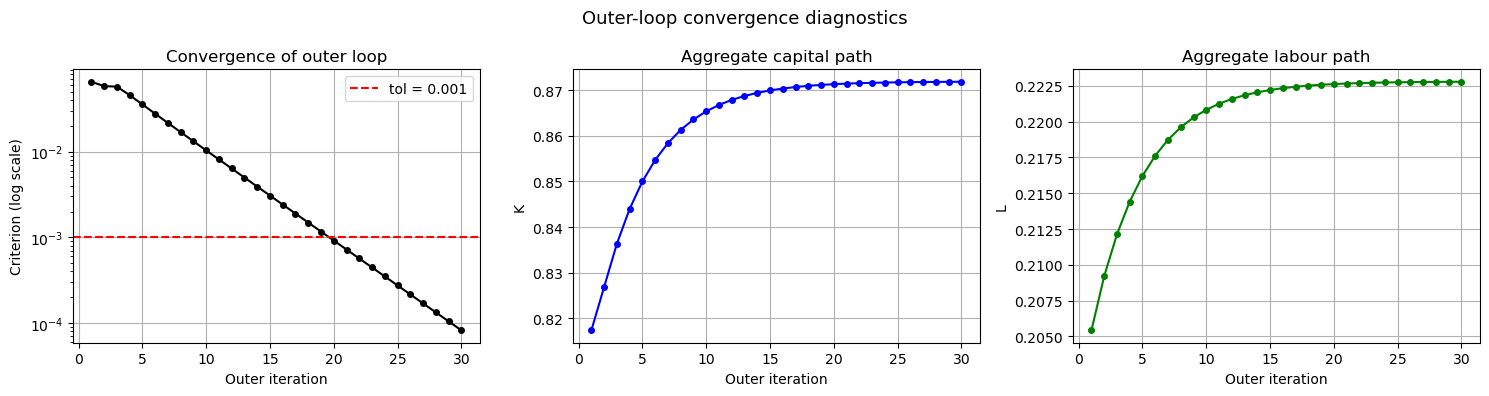

In [33]:
hist = ss['history']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(hist['q'], hist['krit'], 'k-o', markersize=4)
axes[0].axhline(tol, color='r', linestyle='--', label=f'tol = {tol}')
axes[0].set_xlabel('Outer iteration')
axes[0].set_ylabel('Criterion (log scale)')
axes[0].set_title('Convergence of outer loop')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist['q'], hist['kbar'], 'b-o', markersize=4)
axes[1].set_xlabel('Outer iteration')
axes[1].set_ylabel('K')
axes[1].set_title('Aggregate capital path')
axes[1].grid(True)

axes[2].plot(hist['q'], hist['nbar'], 'g-o', markersize=4)
axes[2].set_xlabel('Outer iteration')
axes[2].set_ylabel('L')
axes[2].set_title('Aggregate labour path')
axes[2].grid(True)

plt.suptitle('Outer-loop convergence diagnostics', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Life-Cycle Profiles

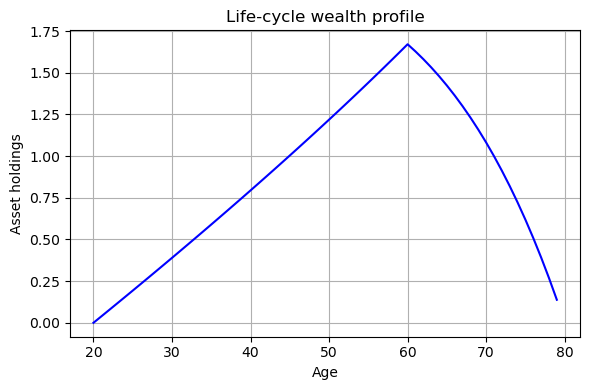

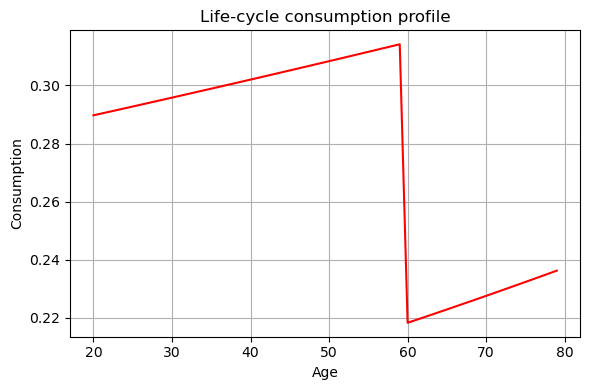

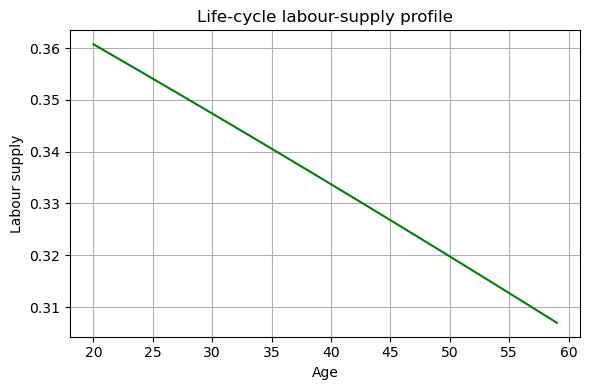

In [36]:
ages         = np.arange(20, 20 + t + tr)   # 20 to 79
ages_workers = np.arange(20, 20 + t)        # 20 to 59

# --- Wealth ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(ages, aopt, 'b-', linewidth=1.5)
ax1.set_xlabel('Age'); ax1.set_ylabel('Asset holdings')
ax1.set_title('Life-cycle wealth profile'); ax1.grid(True)
plt.tight_layout()
fig1.savefig(os.path.join(output_dir, 'olg_ak60_wealth.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Consumption ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(ages, copt, 'r-', linewidth=1.5)
ax2.set_xlabel('Age'); ax2.set_ylabel('Consumption')
ax2.set_title('Life-cycle consumption profile'); ax2.grid(True)
plt.tight_layout()
fig2.savefig(os.path.join(output_dir, 'olg_ak60_consumption.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Labour supply ---
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(ages_workers, nopt, 'g-', linewidth=1.5)
ax3.set_xlabel('Age'); ax3.set_ylabel('Labour supply')
ax3.set_title('Life-cycle labour-supply profile'); ax3.grid(True)
plt.tight_layout()
fig3.savefig(os.path.join(output_dir, 'olg_ak60_labour.png'), dpi=150, bbox_inches='tight')
plt.show()